# 📡 Análisis de tráfico y actividad — Joomla · Nginx · PostgreSQL

**Parcial 2 práctico · Comunicaciones · Ingeniería Mecatrónica**

Este cuaderno se ejecuta **dentro del contenedor `jupyter`**, que está conectado a `frontend_net`
(para hablar con Nginx) y a `backend_net` (para consultar PostgreSQL en `database:5432`).
Las credenciales llegan como variables de entorno desde `.env`, así que no hace falta configurar nada:
basta con **Run → Run All Cells**.

Todas las gráficas son **interactivas** (zoom, *hover*, clic en la leyenda para ocultar series) y las
tablas permiten **buscar, ordenar y paginar**.

| # | Sección | Fuente de datos |
|---|---------|-----------------|
| 0 | Configuración y conexión | `psycopg2` + `SQLAlchemy` |
| 1 | Topología de red vista desde el contenedor (capas 2 y 3) | DNS de Docker `127.0.0.11`, tabla ARP |
| 2 | Generación de tráfico de demostración | peticiones HTTP a `http://nginx/` |
| 3 | Tráfico HTTP del proxy + explorador de logs | `monitoring.nginx_access` |
| 4 | Log de Joomla (Apache) | `monitoring.joomla_access` |
| 5 | Actividad interna de PostgreSQL | `pg_stat_*` |
| 6 | Resumen | — |

> Los logs de Nginx y de Apache se escriben en CSV en volúmenes Docker compartidos y PostgreSQL los
> expone como tablas con la extensión `file_fdw` (ver `database/init/01-monitoring.sql`).
> Por eso **Grafana y este cuaderno ven exactamente los mismos datos** con SQL.

## 0. Configuración y conexión a PostgreSQL


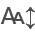

In [1]:
import os, socket, time, urllib.request, urllib.error
from decimal import Decimal

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots
import ipywidgets as w
from IPython.display import HTML, display
from itables import init_notebook_mode, show
from sqlalchemy import create_engine, text

init_notebook_mode(all_interactive=False, connected=False)   # tablas interactivas sin internet

# --- Credenciales (inyectadas por docker-compose desde .env) ---
PG = {k: os.environ.get(f"POSTGRES_{k.upper()}", d) for k, d in
      [("host", "database"), ("port", "5432"), ("db", "joomladb"),
       ("user", "joomla_user"), ("password", "joomla_pass_123")]}
engine = create_engine(
    f"postgresql+psycopg2://{PG['user']}:{PG['password']}@{PG['host']}:{PG['port']}/{PG['db']}",
    connect_args={"application_name": "jupyter"},   # así se identifica en pg_stat_activity
    pool_pre_ping=True,
)


def q(sql, **params):
    """Ejecuta una consulta y devuelve un DataFrame (vacío si falla, para no romper el cuaderno)."""
    try:
        with engine.connect() as conn:
            res = conn.execute(text(sql), params)
            df = pd.DataFrame(res.fetchall(), columns=list(res.keys()))
    except Exception as exc:
        print(f"⚠️  Error en la consulta: {exc.__class__.__name__}: {str(exc).splitlines()[0]}")
        return pd.DataFrame()
    for col in df.columns:   # NUMERIC llega como Decimal → float
        if df[col].map(lambda v: isinstance(v, Decimal)).any():
            df[col] = df[col].astype(float)
    return df


# --- Identidad visual común (mismos colores que Grafana y el portal) ---
COLORES_CLASE = {"1xx": "#8b5cf6", "2xx": "#22c55e", "3xx": "#3b82f6", "4xx": "#f59e0b", "5xx": "#ef4444"}
COLORES_SERVICIO = {"joomla": "#3b82f6", "jupyter": "#f97316", "grafana": "#a855f7"}
pio.templates["parcial"] = go.layout.Template(layout=dict(

    font=dict(family="Inter, Segoe UI, Roboto, Helvetica, Arial, sans-serif", size=13, color="#1e293b"),
    title=dict(font=dict(size=18, color="#0f172a"), x=0.01, xanchor="left"),
    colorway=["#3b82f6", "#f97316", "#a855f7", "#22c55e", "#ef4444", "#14b8a6", "#eab308", "#ec4899"],
    paper_bgcolor="white", plot_bgcolor="#f8fafc",
    xaxis=dict(gridcolor="#e2e8f0", zeroline=False, linecolor="#cbd5e1"),
    yaxis=dict(gridcolor="#e2e8f0", zeroline=False, linecolor="#cbd5e1"),
    hoverlabel=dict(bgcolor="#0f172a", font=dict(color="white", size=12), bordercolor="#0f172a"),
    legend=dict(bgcolor="rgba(0,0,0,0)", orientation="h", yanchor="top", y=-0.12, x=0),
    margin=dict(l=60, r=30, t=70, b=70),
))
pio.templates.default = "plotly_white+parcial"
pio.renderers.default = "plotly_mimetype"
pio.renderers["plotly_mimetype"].width = 1100   # JSON ligero, lo dibuja la extensión de JupyterLab
pd.set_option("display.max_colwidth", 90)

CSS = """
<style>
.pc-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(170px,1fr));gap:14px;margin:8px 0 18px}
.pc-card{border-radius:16px;padding:16px 18px;color:#fff;box-shadow:0 10px 24px rgba(15,23,42,.18);position:relative;overflow:hidden}
.pc-card:after{content:"";position:absolute;right:-30px;top:-30px;width:110px;height:110px;border-radius:50%;background:rgba(255,255,255,.12)}
.pc-card .lbl{font-size:12px;letter-spacing:.06em;text-transform:uppercase;opacity:.85}
.pc-card .val{font-size:30px;font-weight:800;line-height:1.2;margin-top:4px}
.pc-card .sub{font-size:12px;opacity:.85;margin-top:2px}
.pc-banner{border-radius:16px;padding:18px 22px;background:linear-gradient(120deg,#0f2027,#2c5364);color:#fff;
           display:flex;gap:18px;align-items:center;box-shadow:0 10px 24px rgba(15,23,42,.2)}
.pc-dot{width:14px;height:14px;border-radius:50%;background:#22c55e;box-shadow:0 0 0 6px rgba(34,197,94,.25);flex:none}
.pc-tag{display:inline-block;background:rgba(255,255,255,.14);color:#e0f2fe;padding:2px 8px;border-radius:6px;font-family:monospace;margin:2px 0}
.pc-chip{display:inline-block;padding:4px 12px;margin:3px;border-radius:999px;font-weight:600;font-size:13px;color:#fff}
</style>"""
GRADIENTES = ["#2563eb,#0ea5e9", "#7c3aed,#c026d3", "#ea580c,#db2777", "#059669,#14b8a6",
              "#0f766e,#334155", "#4f46e5,#0369a1"]


def tarjetas(items):
    """Muestra indicadores clave como tarjetas con degradado: [(etiqueta, valor, subtítulo), ...]."""
    html = "".join(
        f'<div class="pc-card" style="background:linear-gradient(135deg,{GRADIENTES[i % len(GRADIENTES)]})">'
        f'<div class="lbl">{lbl}</div><div class="val">{val}</div><div class="sub">{sub}</div></div>'
        for i, (lbl, val, sub) in enumerate(items))
    display(HTML(CSS + f'<div class="pc-grid">{html}</div>'))


def tabla(df, **kw):
    """Tabla interactiva (búsqueda, orden, paginación)."""
    opts = dict(classes="display compact cell-border", pageLength=10, lengthMenu=[5, 10, 25, 50],
                maxBytes=0, showIndex=False)
    opts.update(kw)
    show(df, **opts)


info = q("SELECT version() AS version, inet_server_addr() AS ip_servidor, "
         "inet_client_addr() AS ip_cliente, current_database() AS base, "
         "pg_size_pretty(pg_database_size(current_database())) AS tamano")
if not info.empty:
    r = info.iloc[0]
    display(HTML(CSS + f"""
    <div class="pc-banner"><div class="pc-dot"></div><div>
      <div style="font-size:18px;font-weight:800">Conectado a PostgreSQL</div>
      <div style="opacity:.9;margin-top:4px">
        Servidor <span class="pc-tag">{PG['host']} · {r.ip_servidor}:{PG['port']}</span> ·
        cliente <span class="pc-tag">{r.ip_cliente}</span> (jupyter en backend_net) ·
        base <span class="pc-tag">{r.base}</span> ({r.tamano}) ·
        <span class="pc-tag">{r.version.split(',')[0]}</span>
      </div></div></div>"""))

## 1. Topología de red vista desde el contenedor (capas 2 y 3)

El cuaderno consulta el **DNS embebido de Docker** (`127.0.0.11`) para resolver cada servicio y dibuja la
topología con las **IPs reales** de este despliegue. Pasa el cursor sobre cada nodo para ver su imagen,
puerto y direcciones. `database` sólo existe en `backend_net`; `nginx` sólo en `frontend_net`.

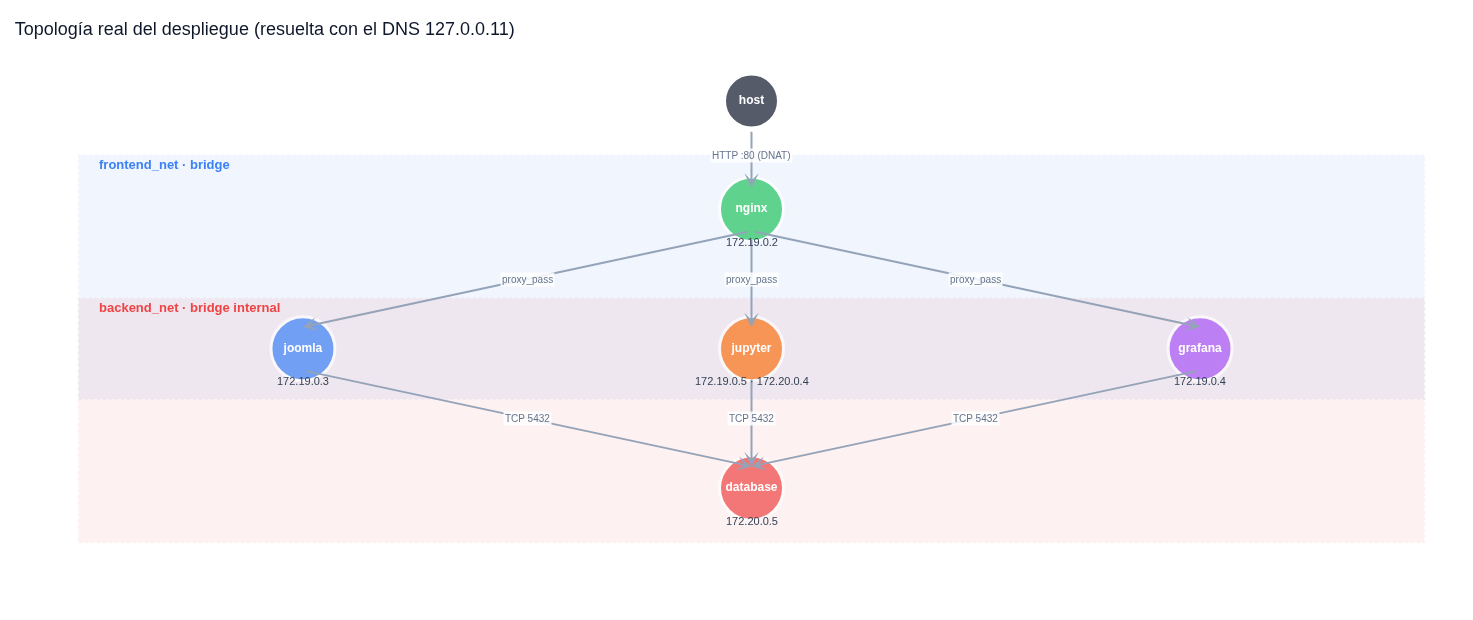

In [2]:
with open("/etc/resolv.conf") as fh:
    dns = [line.split()[1] for line in fh if line.startswith("nameserver")]

SERVICIOS = {
    "nginx":    dict(img="nginx:alpine", puerto="80 (publicado)", pos=(0, 3.0)),
    "joomla":   dict(img="joomla:latest", puerto="80", pos=(-2.4, 1.2)),
    "jupyter":  dict(img="jupyter/minimal-notebook", puerto="8888", pos=(0, 1.2)),
    "grafana":  dict(img="grafana/grafana", puerto="3000", pos=(2.4, 1.2)),
    "database": dict(img="postgres:16-alpine", puerto="5432", pos=(0, -0.6)),
}
ip_a_servicio = {}
# IPs locales de este contenedor (una por red) leídas de la tabla de rutas del kernel
with open("/proc/net/fib_trie") as fh:
    lineas = fh.read().splitlines()
propias = {lineas[i - 1].split()[-1] for i, l in enumerate(lineas) if "/32 host LOCAL" in l} - {"127.0.0.1"}
for nombre, s in SERVICIOS.items():
    try:
        s["ips"] = sorted({ai[4][0] for ai in socket.getaddrinfo(nombre, None, socket.AF_INET)})
    except socket.gaierror:
        s["ips"] = []
    if nombre == "jupyter":
        s["ips"] = sorted(set(s["ips"]) | propias)
    for ip in s["ips"]:
        ip_a_servicio[ip] = nombre

fig = go.Figure()
# Bandas de red (dominios de broadcast)
for y0, y1, nombre, color in [(0.55, 3.7, "frontend_net · bridge", "#3b82f6"),
                              (-1.3, 1.85, "backend_net · bridge internal", "#ef4444")]:
    fig.add_shape(type="rect", x0=-3.6, x1=3.6, y0=y0, y1=y1, line=dict(color=color, width=2, dash="dot"),
                  fillcolor=color, opacity=0.07, layer="below")
    fig.add_annotation(x=-3.5, y=y1 - 0.12, text=f"<b>{nombre}</b>", showarrow=False, xanchor="left",
                       font=dict(color=color, size=13))
# Enlaces
host = (0, 4.4)
enlaces = [(host, "nginx", "HTTP :80 (DNAT)")] + \
          [("nginx", s, "proxy_pass") for s in ("joomla", "jupyter", "grafana")] + \
          [(s, "database", "TCP 5432") for s in ("joomla", "jupyter", "grafana")]
for a, b, etiqueta in enlaces:
    pa = a if isinstance(a, tuple) else SERVICIOS[a]["pos"]
    pb = SERVICIOS[b]["pos"]
    fig.add_annotation(x=pb[0], y=pb[1] + 0.28, ax=pa[0], ay=pa[1] - 0.28, xref="x", yref="y", axref="x", ayref="y",
                       showarrow=True, arrowhead=3, arrowsize=1.2, arrowwidth=2, arrowcolor="#94a3b8")
    fig.add_annotation(x=(pa[0] + pb[0]) / 2, y=(pa[1] + pb[1]) / 2, text=etiqueta, showarrow=False,
                       font=dict(size=10, color="#64748b"), bgcolor="rgba(255,255,255,.85)")
# Nodos
colores_nodo = {"nginx": "#22c55e", "joomla": "#3b82f6", "jupyter": "#f97316", "grafana": "#a855f7", "database": "#ef4444"}
fig.add_trace(go.Scatter(
    x=[s["pos"][0] for s in SERVICIOS.values()] + [host[0]],
    y=[s["pos"][1] for s in SERVICIOS.values()] + [host[1]],
    mode="markers+text", textposition="middle center",
    text=[f"<b>{n}</b>" for n in SERVICIOS] + ["<b>host</b>"],
    textfont=dict(color="white", size=12),
    marker=dict(size=[64] * len(SERVICIOS) + [54], color=list(colores_nodo.values()) + ["#0f172a"],
                line=dict(color="white", width=3), symbol="circle"),
    customdata=[[s["img"], s["puerto"], "<br>".join(s["ips"]) or "no resuelve"] for s in SERVICIOS.values()]
               + [["navegador / curl", "80", "IP del host"]],
    hovertemplate="<b>%{text}</b><br>imagen: %{customdata[0]}<br>puerto: %{customdata[1]}"
                  "<br>IPs: %{customdata[2]}<extra></extra>",
    showlegend=False))
# IPs bajo cada nodo
for n, s in SERVICIOS.items():
    fig.add_annotation(x=s["pos"][0], y=s["pos"][1] - 0.42, text=" · ".join(s["ips"]) or "—",
                       showarrow=False, font=dict(size=11, color="#334155"))
fig.update_layout(title=f"Topología real del despliegue (resuelta con el DNS {', '.join(dns)})",
                  height=620, xaxis=dict(visible=False, range=[-3.7, 3.7]),
                  yaxis=dict(visible=False, range=[-1.4, 4.8]), plot_bgcolor="white")
fig.show()

In [3]:
with open("/proc/net/arp") as fh:
    filas = [l.split() for l in fh.read().splitlines()[1:]]
arp = pd.DataFrame(filas, columns=["IP", "HW type", "Flags", "MAC", "Mask", "Interfaz"])
if arp.empty:
    print("La tabla ARP está vacía todavía (se llena al comunicarse con otros contenedores).")
else:
    arp["Servicio"] = arp["IP"].map(ip_a_servicio).fillna("gateway del bridge / otro")
    print("Tabla ARP del contenedor jupyter: vecinos de capa 2 aprendidos en cada puente")
    tabla(arp[["Servicio", "IP", "MAC", "Interfaz"]], pageLength=5)

Tabla ARP del contenedor jupyter: vecinos de capa 2 aprendidos en cada puente


## 2. Generación de tráfico de demostración

Para que las gráficas tengan datos incluso en un despliegue recién hecho, esta celda envía peticiones
HTTP **a través del proxy** (`http://nginx/…`, por `frontend_net`), incluidas rutas inexistentes para
producir 404. Pon `GENERAR_TRAFICO = False` para omitirla.

In [4]:
GENERAR_TRAFICO = True
RUTAS = ["/", "/index.php", "/index.php/component/users/login", "/index.php?option=com_content",
         "/administrator/", "/no-existe", "/wp-login.php", "/jupyter/api/status"]
RONDAS = 8

if GENERAR_TRAFICO:
    barra = w.IntProgress(min=0, max=RONDAS * len(RUTAS), description="Enviando", bar_style="info",
                          layout=w.Layout(width="60%"))
    display(barra)
    conteo, t0 = {}, time.time()
    for _ in range(RONDAS):
        for ruta in RUTAS:
            req = urllib.request.Request(f"http://nginx{ruta}", headers={"User-Agent": "python-urllib (Jupyter demo)"})
            try:
                with urllib.request.urlopen(req, timeout=10) as resp:
                    codigo = resp.status
            except urllib.error.HTTPError as exc:
                codigo = exc.code
            except Exception:
                codigo = 0
            conteo[codigo] = conteo.get(codigo, 0) + 1
            barra.value += 1
    barra.bar_style, barra.description = "success", "Listo"
    chips = "".join(f'<span class="pc-chip" style="background:{COLORES_CLASE.get(f"{c // 100}xx", "#64748b")}">'
                    f'{c} × {n}</span>' for c, n in sorted(conteo.items()))
    display(HTML(CSS + f"<div>Enviadas <b>{sum(conteo.values())}</b> peticiones en "
                       f"<b>{time.time() - t0:.1f} s</b> → {chips}</div>"))
    time.sleep(1)   # deja que Nginx/Apache escriban las últimas líneas del log

IntProgress(value=0, bar_style='info', description='Enviando', layout=Layout(width='60%'), max=64)

## 3. Tráfico HTTP registrado por Nginx

Cada línea del log de acceso del proxy es una fila de `monitoring.nginx_access`
(IP, servicio de destino, método, URI, código, bytes y tiempos de respuesta).

In [5]:
nginx = q("""
    SELECT ts, ip, servicio, metodo, uri, ruta, status, clase, bytes,
           request_time * 1000 AS latencia_ms, cliente
    FROM monitoring.nginx_access
    WHERE ts > now() - interval '24 hours'
""")
if nginx.empty:
    print("Todavía no hay peticiones registradas: navega por http://localhost/ y vuelve a ejecutar.")
else:
    nginx["ts"] = pd.to_datetime(nginx["ts"], utc=True).dt.tz_convert("America/Bogota").dt.tz_localize(None)
    minutos = max((nginx["ts"].max() - nginx["ts"].min()).total_seconds() / 60, 1)
    tarjetas([
        ("Peticiones", f"{len(nginx):,}", "últimas 24 h"),
        ("Peticiones / min", f"{len(nginx) / minutos:.1f}", "promedio"),
        ("Tasa de error", f"{(nginx['status'] >= 400).mean():.1%}", "respuestas 4xx + 5xx"),
        ("Latencia p95", f"{nginx['latencia_ms'].quantile(.95):.0f} ms", f"p50 = {nginx['latencia_ms'].median():.0f} ms"),
        ("IPs únicas", nginx["ip"].nunique(), "clientes distintos"),
        ("Datos servidos", f"{nginx['bytes'].sum() / 1048576:.2f} MiB", "body_bytes_sent"),
    ])

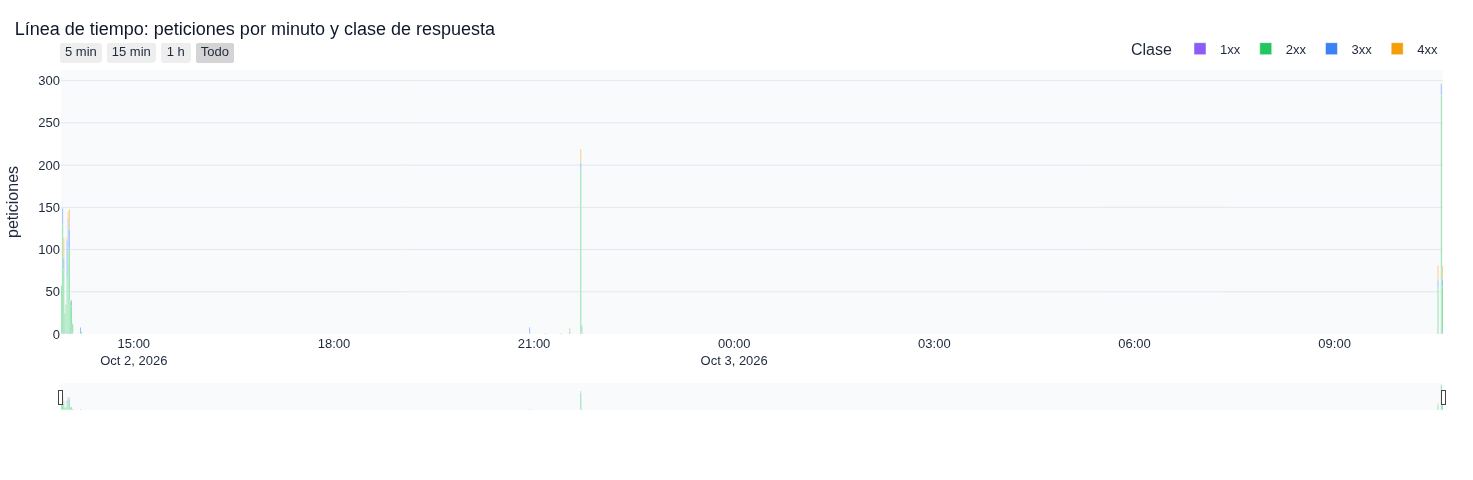

In [6]:
if not nginx.empty:
    por_min = (nginx.assign(minuto=nginx["ts"].dt.floor("min"))
                    .groupby(["minuto", "clase"]).size().reset_index(name="peticiones"))
    fig = px.bar(por_min, x="minuto", y="peticiones", color="clase", color_discrete_map=COLORES_CLASE,
                 category_orders={"clase": sorted(COLORES_CLASE)},
                 title="Línea de tiempo: peticiones por minuto y clase de respuesta",
                 labels={"minuto": "", "peticiones": "peticiones", "clase": "Clase"})
    fig.update_layout(height=480, bargap=0.15, hovermode="x unified",
                      legend=dict(yanchor="bottom", y=1.02, xanchor="right", x=1))
    fig.update_xaxes(rangeslider=dict(visible=True, thickness=0.08), rangeselector=dict(buttons=[
        dict(count=5, label="5 min", step="minute", stepmode="backward"),
        dict(count=15, label="15 min", step="minute", stepmode="backward"),
        dict(count=1, label="1 h", step="hour", stepmode="backward"),
        dict(step="all", label="Todo")]))
    fig.show()

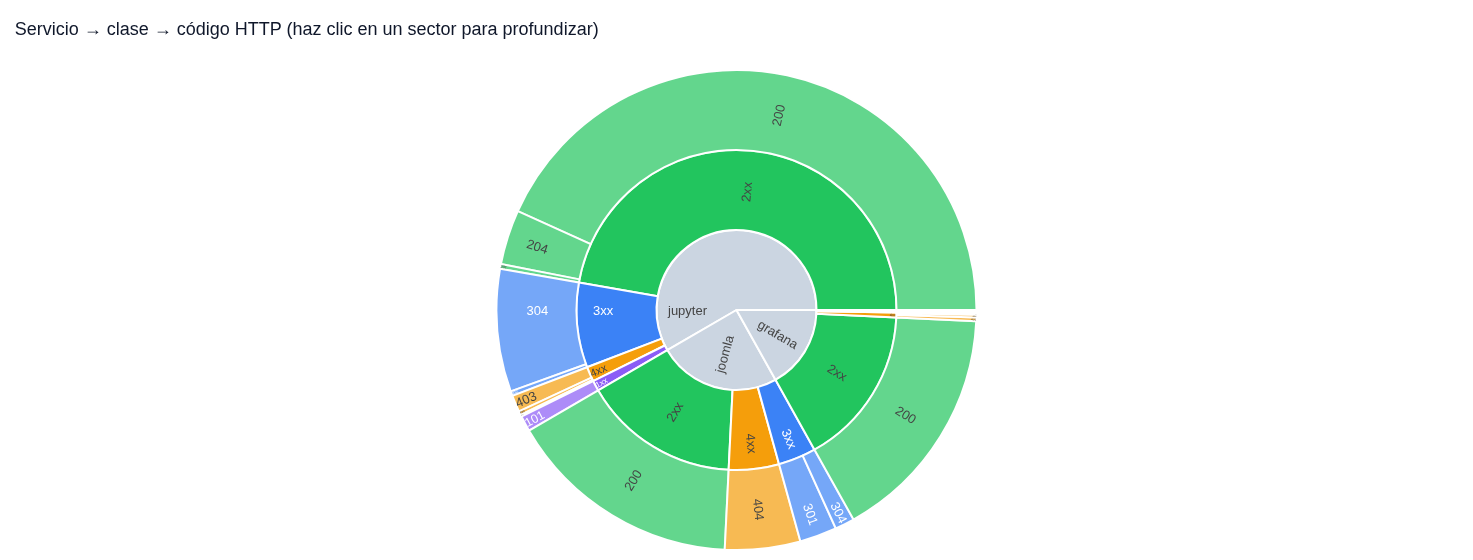

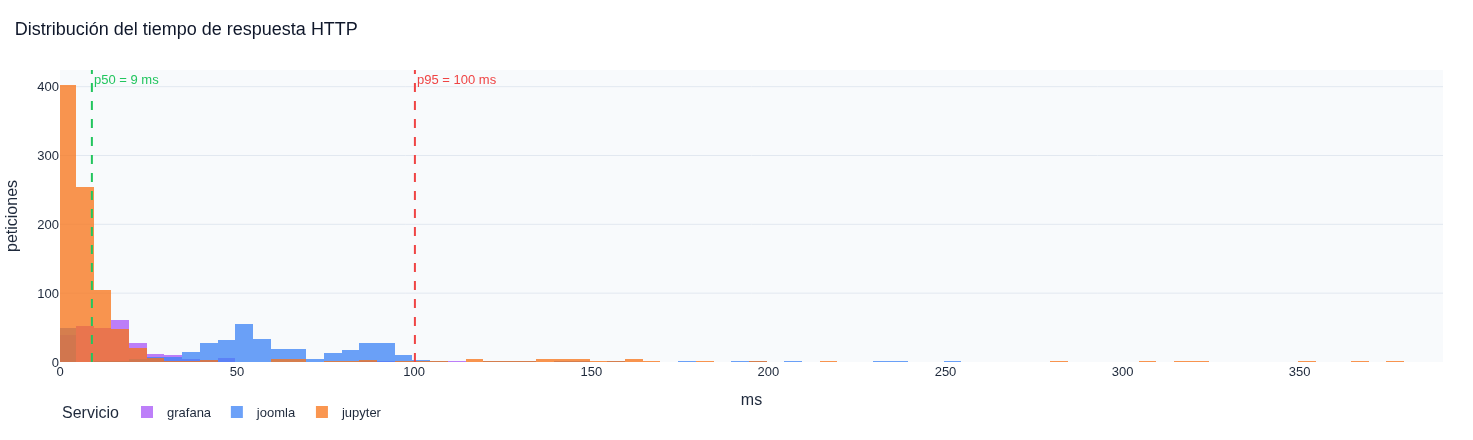

In [7]:
if not nginx.empty:
    sb = nginx.assign(status=nginx["status"].astype(str)).groupby(["servicio", "clase", "status"]).size().reset_index(name="n")
    sun = px.sunburst(sb, path=["servicio", "clase", "status"], values="n", color="clase",
                      color_discrete_map={**COLORES_CLASE, "(?)": "#cbd5e1"},
                      title="Servicio → clase → código HTTP (haz clic en un sector para profundizar)")
    sun.update_traces(marker=dict(line=dict(color="white", width=2)), insidetextorientation="radial",
                      hovertemplate="<b>%{label}</b><br>%{value} peticiones<br>%{percentParent:.1%} del nivel superior<extra></extra>")
    sun.update_layout(height=560, margin=dict(t=70, l=10, r=10, b=10))
    sun.show()

    # Las conexiones WebSocket de Jupyter duran segundos: se excluyen para ver la latencia HTTP real
    http = nginx[nginx["status"] != 101]
    fig = go.Figure()
    for servicio, g in http.groupby("servicio"):
        fig.add_trace(go.Histogram(x=g["latencia_ms"], name=servicio, opacity=0.75,
                                   xbins=dict(size=5), marker_color=COLORES_SERVICIO.get(servicio)))
    for p, color in [(0.5, "#22c55e"), (0.95, "#ef4444")]:
        v = http["latencia_ms"].quantile(p)
        fig.add_vline(x=v, line=dict(color=color, dash="dash", width=2),
                      annotation_text=f"p{int(p * 100)} = {v:.0f} ms", annotation_font_color=color)
    fig.update_layout(barmode="overlay", height=440, title="Distribución del tiempo de respuesta HTTP",
                      xaxis=dict(title="ms", range=[0, http["latencia_ms"].quantile(0.99) * 1.1]),
                      yaxis_title="peticiones", legend_title_text="Servicio")
    fig.show()

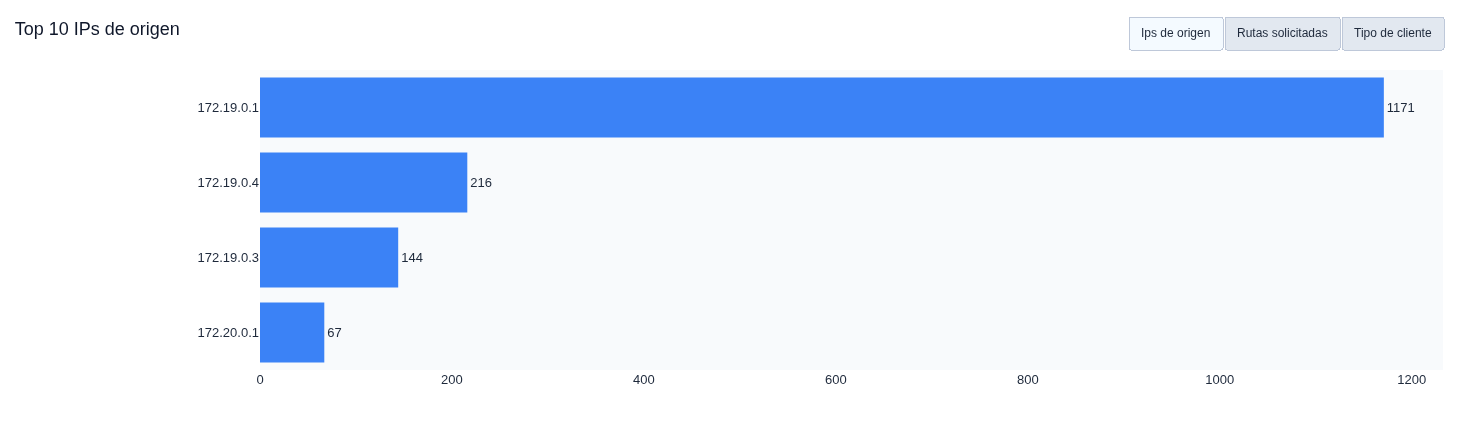

In [8]:
if not nginx.empty:
    top_ips = nginx["ip"].value_counts().head(10).sort_values()
    top_rutas = nginx["ruta"].value_counts().head(10).sort_values()
    top_ua = nginx["cliente"].value_counts().sort_values()
    fig = go.Figure()
    for i, (serie, color) in enumerate([(top_ips, "#3b82f6"), (top_rutas, "#a855f7"), (top_ua, "#f97316")]):
        fig.add_trace(go.Bar(x=serie.values, y=serie.index, orientation="h", visible=(i == 0), text=serie.values,
                             textposition="outside", marker=dict(color=color, line=dict(width=0)),
                             hovertemplate="%{y}: %{x} peticiones<extra></extra>"))
    titulos = ["Top 10 IPs de origen", "Top 10 rutas solicitadas", "Tipo de cliente (User-Agent)"]
    fig.update_layout(
        title=titulos[0], height=440, showlegend=False, margin=dict(l=260),
        updatemenus=[dict(type="buttons", direction="right", x=1, xanchor="right", y=1.18, showactive=True,
                          bgcolor="#e2e8f0", font=dict(size=12),
                          buttons=[dict(label=t.split(" (")[0].replace("Top 10 ", "").capitalize(), method="update",
                                        args=[{"visible": [j == i for j in range(3)]}, {"title": t}])
                                   for i, t in enumerate(titulos)])])
    fig.show()

In [16]:
if not nginx.empty:
    rutas = (nginx.groupby(["servicio", "ruta"])
                  .agg(peticiones=("ts", "size"),
                       errores=("status", lambda s: int((s >= 400).sum())),
                       latencia_media_ms=("latencia_ms", "mean"),
                       p95_ms=("latencia_ms", lambda s: s.quantile(.95)),
                       ultima=("ts", "max"))
                  .round(1).sort_values("peticiones", ascending=False).reset_index())
    rutas["ultima"] = rutas["ultima"].dt.strftime("%H:%M:%S")
    print("Resumen por ruta (usa el buscador y haz clic en los encabezados para ordenar)")
    tabla(rutas, order=[[2, "desc"]])

Resumen por ruta (usa el buscador y haz clic en los encabezados para ordenar)


### 🔎 Explorador de logs

Filtra el log de Nginx por servicio, clase de respuesta y texto en la ruta. La gráfica y la tabla se
actualizan al instante (requiere el kernel en ejecución).

In [18]:
if not nginx.empty:
    f_serv = w.SelectMultiple(options=sorted(nginx["servicio"].unique()), value=tuple(sorted(nginx["servicio"].unique())),
                              description="Servicio", rows=3)
    f_clase = w.SelectMultiple(options=sorted(nginx["clase"].unique()), value=tuple(sorted(nginx["clase"].unique())),
                               description="Clase", rows=4)
    f_txt = w.Text(placeholder="p. ej. login, admin, api…", description="Ruta contiene")
    salida = w.Output()

    def refrescar(*_):
        d = nginx[nginx["servicio"].isin(f_serv.value) & nginx["clase"].isin(f_clase.value)]
        if f_txt.value.strip():
            d = d[d["ruta"].str.contains(f_txt.value.strip(), case=False, regex=False)]
        with salida:
            salida.clear_output(wait=True)
            if d.empty:
                print("Sin coincidencias.")
                return
            fig = px.scatter(d, x="ts", y="latencia_ms", color="clase", color_discrete_map=COLORES_CLASE,
                             symbol="servicio", hover_data=["ip", "metodo", "uri", "status"],
                             title=f"{len(d)} peticiones · latencia de cada una en el tiempo",
                             labels={"ts": "", "latencia_ms": "ms"})
            fig.update_traces(marker=dict(size=9, opacity=0.8, line=dict(width=1, color="white")))
            fig.update_layout(height=440, yaxis_type="log")
            fig.show()
            tabla(d.sort_values("ts", ascending=False)[["ts", "ip", "servicio", "metodo", "uri", "status",
                                                       "latencia_ms", "cliente"]].round(1).head(500))

    for wid in (f_serv, f_clase, f_txt):
        wid.observe(refrescar, names="value")
    display(w.VBox([w.HBox([f_serv, f_clase, f_txt]), salida]))
    refrescar()

## 4. Log de Joomla (Apache dentro del contenedor del CMS)

Apache registra cada petición que le llega desde Nginx en `joomla_access.csv`. Gracias a
`mod_remoteip` la columna `ip` es la del cliente real (tomada de `X-Forwarded-For`), mientras que
`ip_proxy` es la IP de Nginx en `frontend_net`: la evidencia de que todo pasa por el proxy.

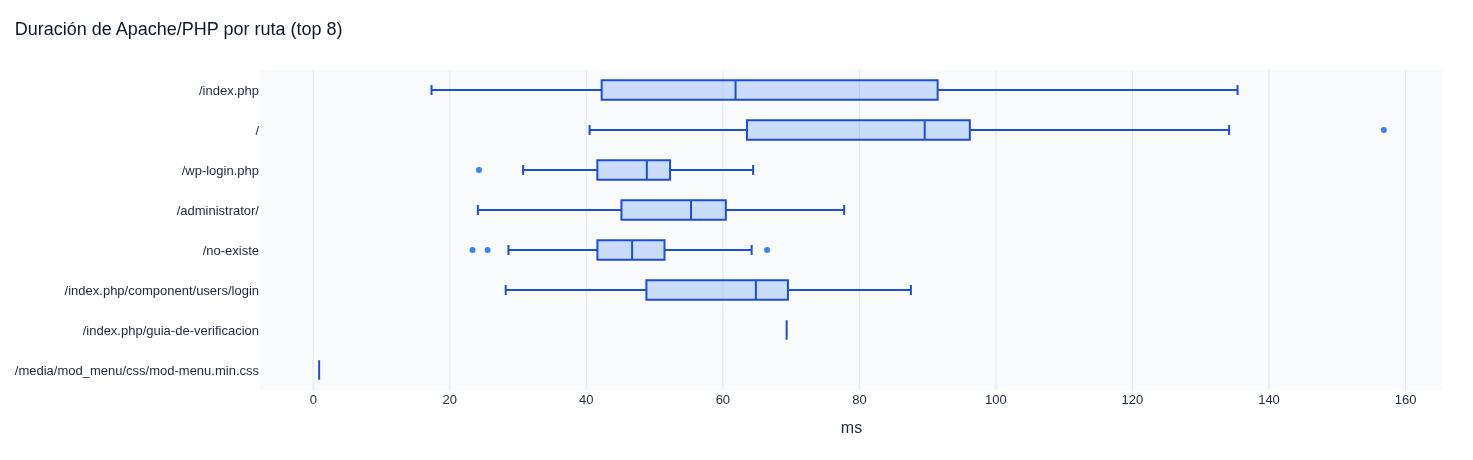

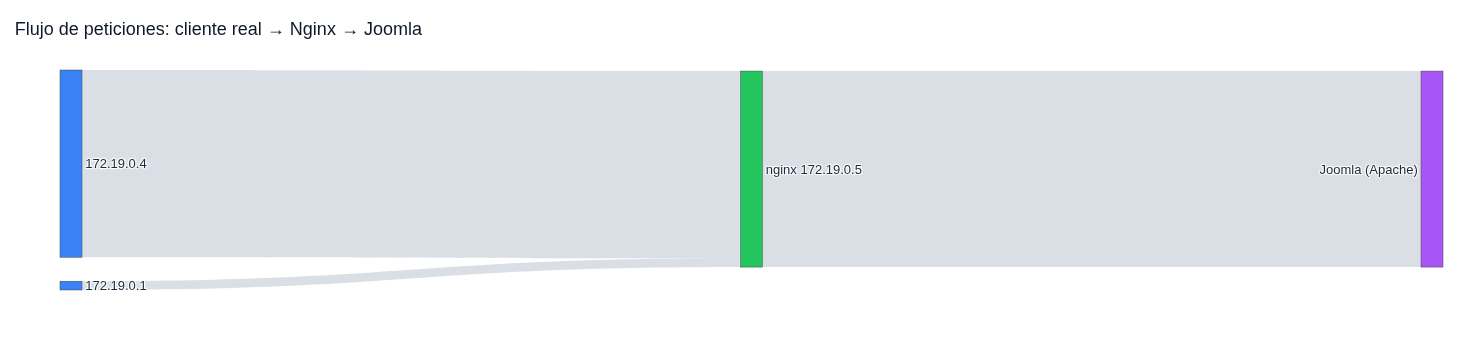

In [11]:
joomla = q("""
    SELECT ts, ip, ip_proxy, metodo, ruta, status, clase, duracion_ms
    FROM monitoring.joomla_access
    WHERE ts > now() - interval '24 hours'
""")
if joomla.empty:
    print("Sin registros de Apache todavía.")
else:
    joomla["ts"] = pd.to_datetime(joomla["ts"], utc=True).dt.tz_convert("America/Bogota").dt.tz_localize(None)
    pares = joomla.groupby(["ip", "ip_proxy"]).size().reset_index(name="peticiones")
    tarjetas([
        ("Peticiones a Joomla", f"{len(joomla):,}", "vistas por Apache"),
        ("Tiempo medio PHP", f"{joomla['duracion_ms'].mean():.0f} ms", f"p95 = {joomla['duracion_ms'].quantile(.95):.0f} ms"),
        ("Proxy observado", ", ".join(joomla["ip_proxy"].unique()), "IP de nginx en frontend_net"),
        ("Clientes reales", joomla["ip"].nunique(), "restaurados con X-Forwarded-For"),
    ])

    orden = joomla["ruta"].value_counts().head(8).index
    fig = go.Figure()
    for ruta in orden[::-1]:
        fig.add_trace(go.Box(x=joomla.loc[joomla["ruta"] == ruta, "duracion_ms"], name=ruta, orientation="h",
                             boxpoints="outliers", marker_color="#3b82f6", line_color="#1d4ed8",
                             fillcolor="rgba(59,130,246,.25)", showlegend=False))
    fig.update_layout(title="Duración de Apache/PHP por ruta (top 8)", xaxis_title="ms", height=460,
                      margin=dict(l=260))
    fig.show()

    nodos = list(pares["ip"].unique()) + [f"nginx {p}" for p in pares["ip_proxy"].unique()] + ["Joomla (Apache)"]
    idx = {n: i for i, n in enumerate(nodos)}
    proxies = pares.groupby("ip_proxy")["peticiones"].sum()
    sankey = go.Figure(go.Sankey(
        node=dict(label=nodos, pad=24, thickness=22,
                  color=["#3b82f6"] * pares["ip"].nunique() + ["#22c55e"] * len(proxies) + ["#a855f7"]),
        link=dict(source=[idx[r.ip] for r in pares.itertuples()] + [idx[f"nginx {p}"] for p in proxies.index],
                  target=[idx[f"nginx {r.ip_proxy}"] for r in pares.itertuples()] + [idx["Joomla (Apache)"]] * len(proxies),
                  value=list(pares["peticiones"]) + list(proxies.values),
                  color="rgba(148,163,184,.35)")))
    sankey.update_layout(title="Flujo de peticiones: cliente real → Nginx → Joomla", height=360)
    sankey.show()

## 5. Actividad interna de PostgreSQL

Cada visita a Joomla genera lecturas y escrituras (sesión, menús, extensiones…). Las vistas de
estadísticas de PostgreSQL lo reflejan sin depender del prefijo de las tablas del CMS.

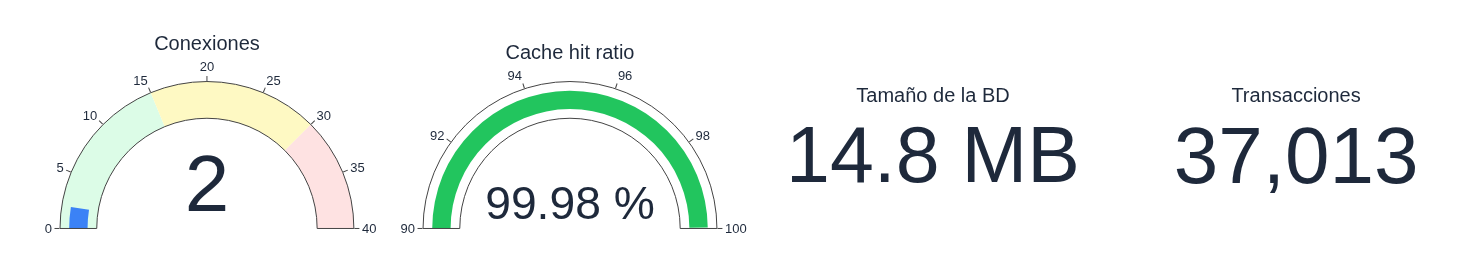

In [12]:
estado = q("""
    SELECT (SELECT count(*) FROM pg_stat_activity WHERE datname = current_database()) AS conexiones,
           100.0 * blks_hit / NULLIF(blks_hit + blks_read, 0) AS cache_hit,
           pg_database_size(current_database()) / 1048576.0 AS tamano_mb,
           xact_commit + xact_rollback AS transacciones
    FROM pg_stat_database WHERE datname = current_database()
""")
if not estado.empty:
    e = estado.iloc[0]
    fig = make_subplots(rows=1, cols=4, specs=[[{"type": "indicator"}] * 4])
    fig.add_trace(go.Indicator(mode="gauge+number", value=e.conexiones, title={"text": "Conexiones"},
                               gauge=dict(axis=dict(range=[0, 40]), bar=dict(color="#3b82f6"),
                                          steps=[dict(range=[0, 15], color="#dcfce7"), dict(range=[15, 30], color="#fef9c3"),
                                                 dict(range=[30, 40], color="#fee2e2")])), 1, 1)
    fig.add_trace(go.Indicator(mode="gauge+number", value=e.cache_hit, number={"suffix": " %", "valueformat": ".2f"},
                               title={"text": "Cache hit ratio"},
                               gauge=dict(axis=dict(range=[90, 100]), bar=dict(color="#22c55e"))), 1, 2)
    fig.add_trace(go.Indicator(mode="number", value=e.tamano_mb, number={"suffix": " MB", "valueformat": ".1f"},
                               title={"text": "Tamaño de la BD"}), 1, 3)
    fig.add_trace(go.Indicator(mode="number", value=e.transacciones, number={"valueformat": ",d"},
                               title={"text": "Transacciones"}), 1, 4)
    fig.update_layout(height=260, margin=dict(t=60, b=10))
    fig.show()

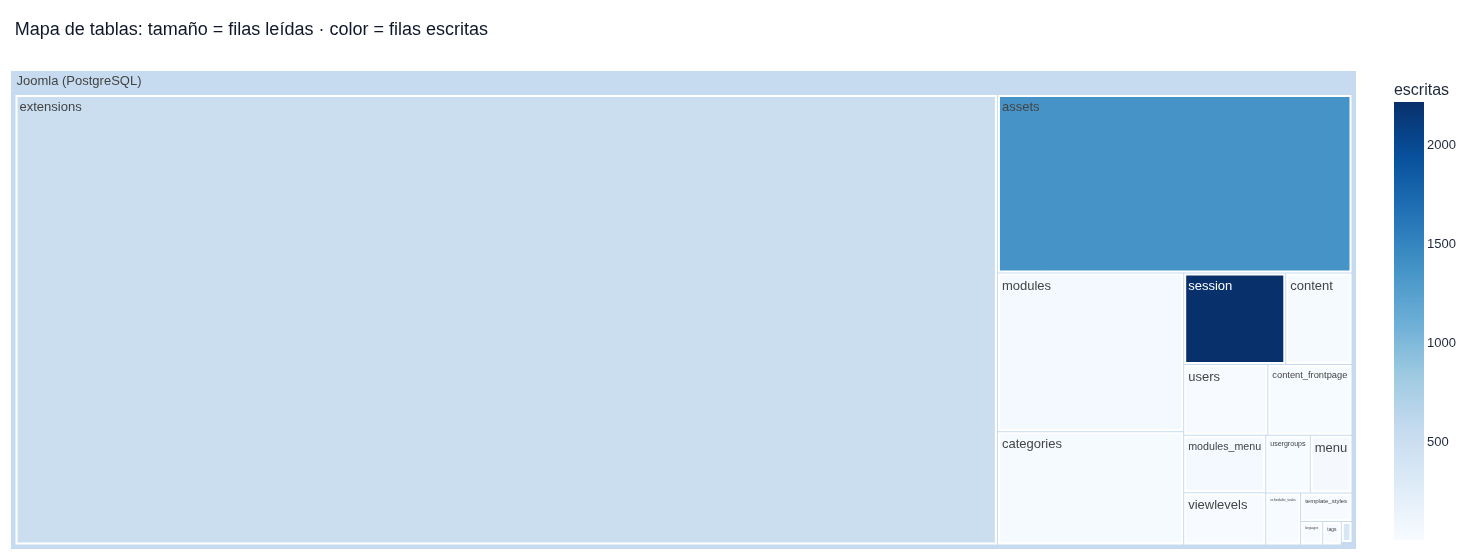

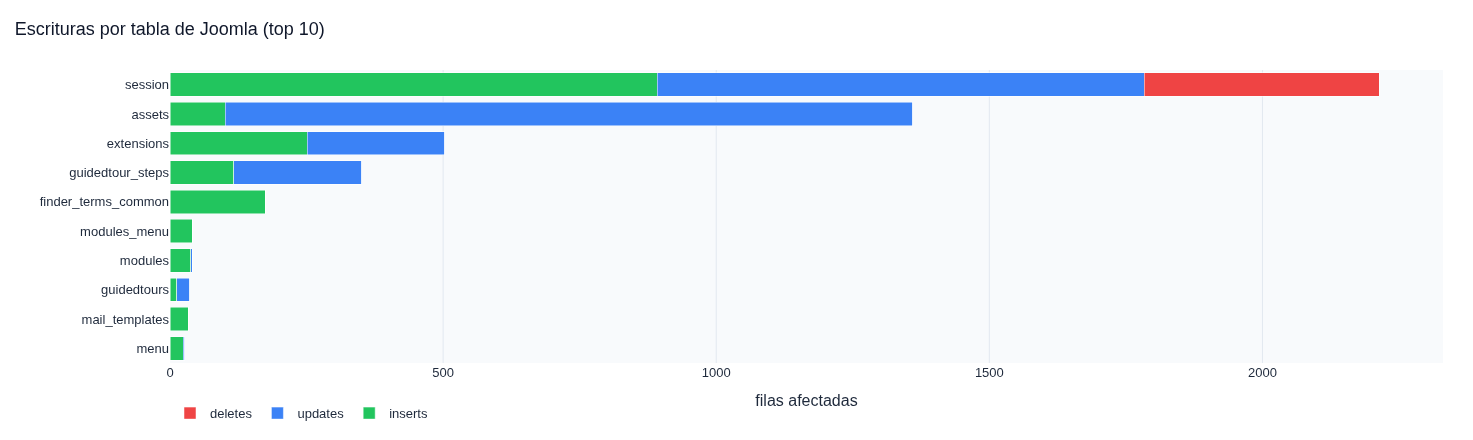

In [13]:
tablas = q("""
    SELECT regexp_replace(relname, '^[a-z0-9]+_', '') AS tabla,
           n_tup_ins AS inserts, n_tup_upd AS updates, n_tup_del AS deletes,
           COALESCE(seq_tup_read, 0) + COALESCE(idx_tup_fetch, 0) AS lecturas
    FROM pg_stat_user_tables WHERE schemaname = 'public'
""")
if not tablas.empty:
    tablas["escrituras"] = tablas[["inserts", "updates", "deletes"]].sum(axis=1)
    activas = tablas[tablas["lecturas"] > 0]
    fig = px.treemap(activas, path=[px.Constant("Joomla (PostgreSQL)"), "tabla"], values="lecturas",
                     color="escrituras", color_continuous_scale="Blues",
                     custom_data=["inserts", "updates", "deletes", "escrituras"],
                     title="Mapa de tablas: tamaño = filas leídas · color = filas escritas")
    fig.update_traces(marker=dict(line=dict(color="white", width=2)), root_color="#f1f5f9",
                      hovertemplate="<b>%{label}</b><br>leídas: %{value:,}<br>escritas: %{customdata[3]:,}"
                                    "<br>inserts %{customdata[0]:,} · updates %{customdata[1]:,} · deletes %{customdata[2]:,}<extra></extra>")
    fig.update_layout(height=560, margin=dict(t=70, l=10, r=10, b=10), coloraxis_colorbar_title="escritas")
    fig.show()

    top = tablas.sort_values("escrituras", ascending=False).head(10).iloc[::-1]
    fig = go.Figure([go.Bar(y=top["tabla"], x=top[c], name=c, orientation="h", marker_color=col)
                     for c, col in [("inserts", "#22c55e"), ("updates", "#3b82f6"), ("deletes", "#ef4444")]])
    fig.update_layout(barmode="stack", title="Escrituras por tabla de Joomla (top 10)", height=440,
                      xaxis_title="filas afectadas", margin=dict(l=170))
    fig.show()

In [19]:
conexiones = q("""
    SELECT pid, COALESCE(host(client_addr), 'local') AS ip_cliente,
           COALESCE(NULLIF(application_name, ''), '(sin nombre)') AS aplicacion,
           state AS estado, backend_start AS conectado_desde,
           LEFT(regexp_replace(query, '\s+', ' ', 'g'), 100) AS ultima_consulta
    FROM pg_stat_activity WHERE datname = current_database()
    ORDER BY backend_start
""")
if not conexiones.empty:
    conexiones["servicio"] = conexiones["ip_cliente"].map(ip_a_servicio).fillna("—")
    conexiones["conectado_desde"] = pd.to_datetime(conexiones["conectado_desde"], utc=True) \
        .dt.tz_convert("America/Bogota").dt.strftime("%H:%M:%S")
    print("Sesiones abiertas en PostgreSQL (la IP se traduce a servicio con el DNS de Docker)")
    tabla(conexiones[["pid", "servicio", "ip_cliente", "aplicacion", "estado", "conectado_desde", "ultima_consulta"]])

Sesiones abiertas en PostgreSQL (la IP se traduce a servicio con el DNS de Docker)


## 6. Resumen

In [15]:
items = []
if not nginx.empty:
    items += [("Tráfico Nginx", f"{len(nginx):,}", f"{nginx['ip'].nunique()} IP(s) · {(nginx['status'] >= 400).mean():.0%} errores"),
              ("Latencia proxy", f"{nginx['latencia_ms'].median():.0f} ms", f"p95 = {nginx['latencia_ms'].quantile(.95):.0f} ms")]
if not joomla.empty:
    items.append(("Joomla / Apache", f"{len(joomla):,}", f"todas desde el proxy {', '.join(joomla['ip_proxy'].unique())}"))
if not tablas.empty:
    t = tablas.sort_values("escrituras", ascending=False).iloc[0]
    items.append(("Tabla más escrita", t.tabla, f"{int(t.escrituras):,} filas afectadas"))
if not conexiones.empty:
    items.append(("Sesiones PostgreSQL", len(conexiones), f"desde {conexiones['ip_cliente'].nunique()} contenedor(es) de backend_net"))
if items:
    tarjetas(items)
else:
    print("No hay datos todavía.")